# Validacion del modelo: curvas de sintonia (Q10dB)

- **Humano**: comparacion cuantitativa contra Q_ERB (Moore & Glasberg, 1983), analitica.
- **Gato**: diagnostico visual unicamente -- la referencia fisiologica (Kiang & Moxon, 1972, via Fig. 12 de Neely & Kim) no se pudo digitalizar con fiabilidad suficiente a partir del escaneo disponible; se deja como comparacion cualitativa, sin tabla de error.

In [5]:
import numpy as np
from cochleasim.models.params_loader import CAT_PARAMS, HUMAN_PARAMS
from cochleasim.analysis.response import q10db_at_cf
from cochleasim.validation.reference import load_erb_q_curve
from cochleasim.validation.compare import compare_curves

ImportError: cannot import name 'q10db_at_cf' from 'cochleasim.analysis.response' (C:\Users\Antonio Perez Lopez\Documents\UPV\TFG\cochleasim\cochleasim\analysis\response.py)

## Humano vs. Q_ERB

In [2]:
targets = np.logspace(np.log10(150), np.log10(8000), 20)
measured = [q10db_at_cf(HUMAN_PARAMS, f, N=1000) for f in targets]
model_cf, model_q = zip(*[(cf, q) for cf, bw, q in measured if not np.isnan(q)])

result = compare_curves({'Human': (model_cf, model_q)}, load_erb_q_curve())
result.plot(xlabel='CF (Hz)', ylabel='Q10dB')

NameError: name 'q10db_at_cf' is not defined

In [3]:
errs = [row['error'] for row in result.summary_table() if not np.isnan(row['error'])]
print(f'mediana del error: {np.median(errs):.0f}%  (n={len(errs)})')

NameError: name 'result' is not defined

## Gato -- diagnostico visual (sin referencia numerica)

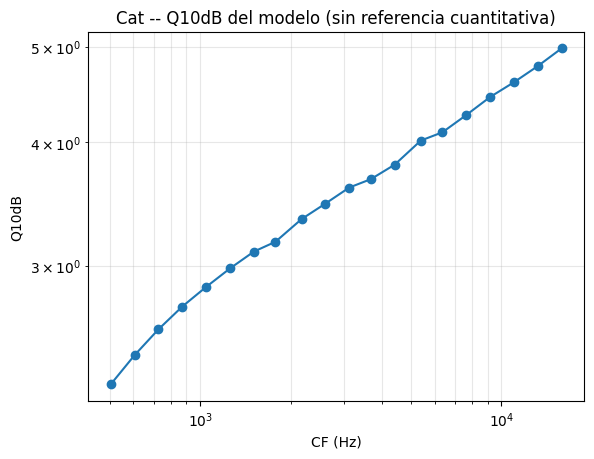

In [4]:
targets_cat = np.logspace(np.log10(500), np.log10(16000), 20)
measured_cat = [q10db_at_cf(CAT_PARAMS, f, N=1000) for f in targets_cat]
cat_cf, cat_q = zip(*[(cf, q) for cf, bw, q in measured_cat if not np.isnan(q)])

import matplotlib.pyplot as plt
plt.loglog(cat_cf, cat_q, 'o-')
plt.xlabel('CF (Hz)')
plt.ylabel('Q10dB')
plt.title('Cat -- Q10dB del modelo (sin referencia cuantitativa)')
plt.grid(True, which='both', alpha=0.3)
plt.show()